<a href="https://colab.research.google.com/github/nourswaid/ML-A_Z-/blob/main/Reinforcement%20Learning/thompson_sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thompson Sampling

## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [2]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

## Implementing Thompson Sampling

In [23]:
import random
N = 500
d = 10
ads_selected = []
numbers_of_rewards_1= [0]*d
numbers_of_rewards_0=[0]*d
total_reward = 0

for n in range(0,N):
  ad=0
  max_random = 0
  for i in range(0,d):
    random_beta=random.betavariate(numbers_of_rewards_1[i]+1,numbers_of_rewards_0[i]+1)
    if max_random<random_beta:
      max_random=random_beta
      ad=i
  ads_selected.append(ad)
  reward=dataset.values[n,ad]
  if reward==1:
    numbers_of_rewards_1[ad]=numbers_of_rewards_1[ad]+1
  else:
    numbers_of_rewards_0[ad]=numbers_of_rewards_0[ad]+1
  total_reward=total_reward+reward


## Visualising the results - Histogram

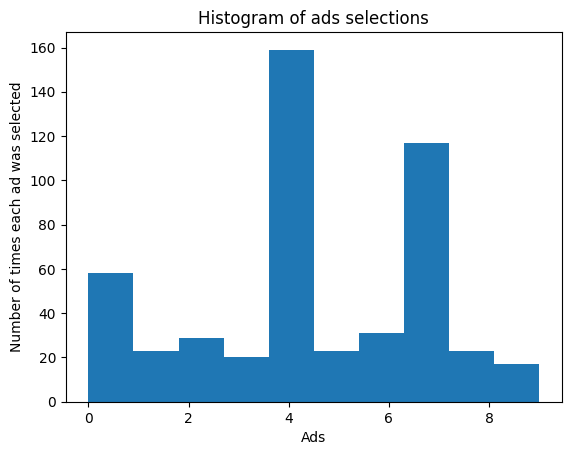

In [24]:


plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()

In [ ]:
# Thompson sampling is more powerfull than UCB in most situation
# got the best add with only 500 iteration